## Wearable Tech: Week 2 Assignment

### Step 1

In [2]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
# imports
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime

#turns off warning for chained assignment as we are overwriting references to original dataframe
pd.options.mode.chained_assignment = None  # default='warn'
pd.set_option('display.max_rows', 30)

df = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 4 - Wearable Technologies and Sports Analytics/Week 2 Content/Week 2 Assignment/Soccer.csv", parse_dates=["Date"])

### Step 2

In [62]:
# Make a new dataset (or dataframe) using only the “session” periods from the season
session_df = df.loc[df['Period.Name'] == "Session"]

session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06
1,89,Session,GK,238.00543,14.04880,205,101,174.15563,2019-08-06
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06
...,...,...,...,...,...,...,...,...,...
9499,23,Session,GK,185.24280,4.66020,0,0,0.00000,2019-11-24
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24


### Step 3

In [63]:
# Create a variable for the “session duration” based on the “total player load” and the “player load per minute” columns.
session_df['Session.Duration'] = session_df['Total.Player.Load']/session_df['Player.Load.Per.Minute']
session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Date,Session.Duration
0,12,Session,D,276.85373,15.33448,205,0,170.91685,2019-08-06,18.054328
1,89,Session,GK,238.00543,14.04880,205,101,174.15563,2019-08-06,16.941335
2,63,Session,F,231.84551,14.36184,206,0,179.25900,2019-08-06,16.143162
3,15,Session,D,355.02606,18.78379,216,0,177.66543,2019-08-06,18.900662
4,44,Session,D,318.82076,17.41175,218,0,180.77740,2019-08-06,18.310667
...,...,...,...,...,...,...,...,...,...,...
9499,23,Session,GK,185.24280,4.66020,0,0,0.00000,2019-11-24,39.749968
9500,21,Session,D,1364.75000,9.87637,129,0,129.00000,2019-11-24,138.183361
9501,43,Session,M,1294.72809,11.25361,225,0,166.42591,2019-11-24,115.050023
9502,91,Session,F,633.34450,6.94490,128,0,128.00000,2019-11-24,91.195626


### Step 4

In [64]:
# Rank the team players by their cumulative playerload across the entire season
Rank_Total_PL = session_df.groupby(['Player.Name', 'Position.Name'])[['Total.Player.Load']].sum()
print("Total duration captured for entire season")
print(Rank_Total_PL.sort_values(by='Total.Player.Load', ascending = False))

Total duration captured for entire season
                           Total.Player.Load
Player.Name Position.Name                   
43          M                    61807.06587
62          F                    55455.84319
4           M                    54531.06541
21          D                    52448.84502
44          D                    45528.61318
66          M                    44035.16557
100         D                    43435.17877
39          D                    42966.83272
12          D                    42594.47149
52          D                    41966.27363
35          F                    39743.46043
86          M                    38332.92067
10          D                    35760.14918
63          F                    34497.65386
15          D                    32792.41598
18          D                    28582.29879
97          F                    28388.64588
49          F                    28331.33281
91          F                    27545.34959
48          M

### Step 5

In [65]:
# 5. Determine the 10 highest sessions for playerload (by any player) and observe how many of these occurred on “game” days
Rank_Session_Total = session_df.groupby(['Date','Player.Name'])[['Total.Player.Load']].max()
print(Rank_Session_Total.sort_values(by='Total.Player.Load', ascending = False).head(10))

                        Total.Player.Load
Date       Player.Name                   
2019-11-08 43                  1755.08710
2019-11-22 43                  1701.65860
2019-09-19 62                  1695.69403
           43                  1672.69440
2019-09-13 43                  1649.17551
2019-09-29 4                   1641.06146
2019-09-01 43                  1635.75719
2019-09-29 43                  1617.42587
2019-11-08 62                  1576.30459
2019-10-03 4                   1565.28558


Comparing the top 10 highest sessions for playerload (by any player) to the list of gamedays, we can see that all 10 of them occurred on gamedays.


### Step 6

In [66]:
# Remove the two players with the lowest cumulative player load (who we previously identified as missing many training sessions; players 98 and 62)
# as well as any other goalkeepers from the dataset (Players 89, 23 and 71)
session_df=session_df.set_index('Player.Name')
session_df=session_df.drop([98, 62, 89, 23, 71])
session_df=session_df.set_index('Date', append=True)
session_df.reset_index(level=['Player.Name'], inplace=True)
session_df['Player.Name'] = session_df['Player.Name'].astype('object')
session_df

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration
Date,,,,,,,,,
2019-08-06,12,Session,D,276.85373,15.33448,205,0,170.91685,18.054328
2019-08-06,63,Session,F,231.84551,14.36184,206,0,179.25900,16.143162
2019-08-06,15,Session,D,355.02606,18.78379,216,0,177.66543,18.900662
2019-08-06,44,Session,D,318.82076,17.41175,218,0,180.77740,18.310667
2019-08-06,35,Session,F,315.51553,16.69335,0,0,0.00000,18.900672
...,...,...,...,...,...,...,...,...,...
2019-11-24,100,Session,D,1161.67722,9.04267,127,0,127.00000,128.466174
2019-11-24,21,Session,D,1364.75000,9.87637,129,0,129.00000,138.183361
2019-11-24,43,Session,M,1294.72809,11.25361,225,0,166.42591,115.050023


### Step 7

In [67]:
# Plot the ACWR (using the 3 day acute and 21-day chronic windows) for the player identified as having the highest cumulative player load in step 4 above.
df_43 = session_df.loc[session_df['Player.Name'] == 43]
df_43 = df_43.resample('D').sum()
df_43 = df_43.fillna(0)
df_43

/tmp/ipykernel_3059/2096926598.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_43 = df_43.fillna(0)


,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration
Date,,,,,,,,,
2019-08-06,129,SessionSessionSession,MMM,1384.29407,35.61502,624,0,481.55868,148.599858
2019-08-07,86,SessionSession,MM,1231.07260,12.98502,399,0,289.58705,192.827240
2019-08-08,0,0,0,0.00000,0.00000,0,0,0.00000,0.000000
2019-08-09,86,SessionSession,MM,1258.91826,15.41278,406,0,297.78315,163.980353
2019-08-10,43,Session,M,614.87480,7.13326,219,0,132.28724,86.198288
...,...,...,...,...,...,...,...,...,...
2019-11-20,43,Session,M,323.13271,6.67317,203,0,134.71798,48.422670
2019-11-21,43,Session,M,329.35446,6.99762,80,80,80.00000,47.066640
2019-11-22,43,Session,M,1701.65860,12.84722,229,0,168.91000,132.453449


In [68]:
# We will create 2 new columns to store the 3-day and 21-day moving averages, titled "Acute_PL" and "Chronic_PL", respectively.
# We will also create a new column titled "Acute:Chronic" that stores the acute to chronic player load ratio.
df_43["Acute_PL"] = (df_43.loc[:,"Total.Player.Load"].rolling('3D', 3).sum())/3
df_43["Chronic_PL"] = (df_43.loc[:,"Total.Player.Load"].rolling('21D', 21).sum())/21
df_43["Acute:Chronic"] = df_43.loc[:,"Acute_PL"]/df_43.loc[:,"Chronic_PL"]
df_43

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,,,,
2019-08-06,129,SessionSessionSession,MMM,1384.29407,35.61502,624,0,481.55868,148.599858,NaN,NaN,NaN
2019-08-07,86,SessionSession,MM,1231.07260,12.98502,399,0,289.58705,192.827240,NaN,NaN,NaN
2019-08-08,0,0,0,0.00000,0.00000,0,0,0.00000,0.000000,871.788890,NaN,NaN
2019-08-09,86,SessionSession,MM,1258.91826,15.41278,406,0,297.78315,163.980353,829.996953,NaN,NaN
2019-08-10,43,Session,M,614.87480,7.13326,219,0,132.28724,86.198288,624.597687,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-20,43,Session,M,323.13271,6.67317,203,0,134.71798,48.422670,359.682643,468.288363,0.768079
2019-11-21,43,Session,M,329.35446,6.99762,80,80,80.00000,47.066640,315.844243,465.212515,0.678925
2019-11-22,43,Session,M,1701.65860,12.84722,229,0,168.91000,132.453449,784.715257,526.936962,1.489201


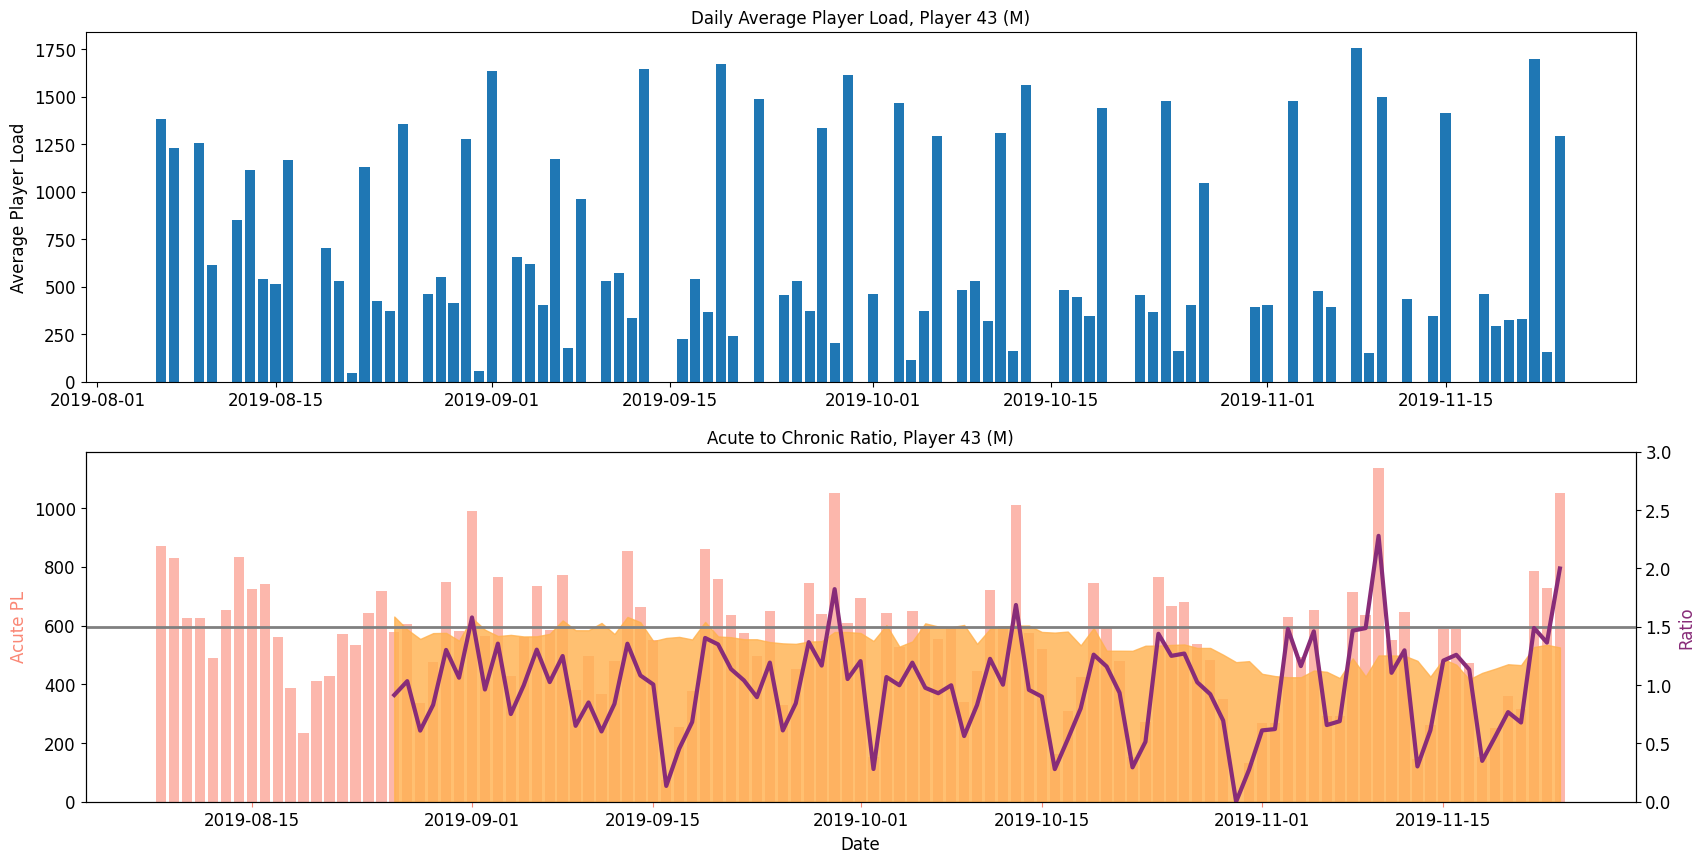

In [69]:
fig, axs = plt.subplots(2,figsize=(20, 10))

axs[0].bar(df_43.index, df_43["Total.Player.Load"])
#axs[0].set_xlabel("Date", fontsize=12)
axs[0].tick_params(axis='x', labelsize=12,)
axs[0].set_ylabel('Average Player Load', fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].set_title("Daily Average Player Load, Player 43 (M)", fontsize=12)

color='#FA8775'
axs[1].set_xlabel("Date", fontsize=12)
axs[1].tick_params(axis='x', labelsize=12, color=color)
axs[1].set_ylabel('Acute PL', color=color, fontsize=12)
axs[1].bar(df_43.index, df_43["Acute_PL"], color=color, alpha=0.6)
axs[1].tick_params(axis='y', labelsize=12)
color='#FFB14E'
axs[1].fill_between(df_43.index, df_43["Chronic_PL"], color=color, alpha=0.8)
axs[1] = plt.gca()
axs[1].set_title("Acute to Chronic Ratio, Player 43 (M)", fontsize=12)
axs1 = axs[1].twinx()  # instantiate a second axes that shares the same x-axis

color='#882C78'
axs1.set_ylabel('Ratio', fontsize=12, color=color)  # we already handled the x-label with ax1
axs1.plot(df_43.index, df_43["Acute:Chronic"], color=color, linewidth=3.0)
axs1.tick_params(axis='y', labelsize=12)
axs1 = plt.gca()

# To see how the acute to chronic workload ratio drops over the first 28 days,
# comment out this line by adding a '#' in front of the line
axs1.set_ylim([0,3.0])

axs1.axhline(y=1.5,c="gray",linewidth=2,zorder=0)

In [71]:
df_43.nlargest(6, 'Acute:Chronic')

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,,,,
2019-11-10,43,Session,M,1501.18530,11.00612,163,0,156.31941,136.395505,1135.440377,498.234032,2.278930
2019-11-24,43,Session,M,1294.72809,11.25361,225,0,166.42591,115.050023,1050.789233,525.609315,1.999183
2019-09-29,43,Session,M,1617.42587,11.99220,225,0,166.82273,134.873157,1053.229680,578.014139,1.822152
2019-10-13,43,Session,M,1562.56041,11.17316,217,0,160.25297,139.849462,1012.018400,600.113996,1.686377
2019-09-01,43,Session,M,1635.75719,9.69604,210,0,150.83079,168.703635,989.304657,626.384239,1.579389
2019-11-22,43,Session,M,1701.65860,12.84722,229,0,168.91000,132.453449,784.715257,526.936962,1.489201


### Step 8

In [72]:
# Plot the ACWR (using the 3 day acute and 21-day chronic windows) for the entire team
df_all = session_df.groupby("Date").sum()
df_all = df_all.resample('D').sum()
df_all = df_all.fillna(0)

df_all["Acute_PL"] = (df_all.loc[:,"Total.Player.Load"].rolling('3D', 3).sum())/3
df_all["Chronic_PL"] = (df_all.loc[:,"Total.Player.Load"].rolling('21D', 21).sum())/21
df_all["Acute:Chronic"] = df_all.loc[:,"Acute_PL"]/df_all.loc[:,"Chronic_PL"]
df_all.head(30)

/tmp/ipykernel_3059/3102976489.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all = df_all.fillna(0)


,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,,,,
2019-08-06,2696,SessionSessionSessionSessionSessionSessionSess...,DFDDFFDFMMDFMMMDDMDDFDDFFDFMMDFMMMDDMDDFDDFFDF...,21457.62648,578.47427,9810,1464,7896.95444,2718.800956,NaN,NaN,NaN
2019-08-07,2367,SessionSessionSessionSessionSessionSessionSess...,DFDFMMDMMDDDFDDFFDFMMDFMMMDDMDDFDDFFDFMMDFMMMD...,21576.70582,320.09410,9141,1221,6727.04942,3960.461380,NaN,NaN,NaN
2019-08-08,0,0,0,0.00000,0.00000,0,0,0.00000,0.000000,14344.777433,NaN,NaN
2019-08-09,1935,SessionSessionSessionSessionSessionSessionSess...,DFDDFFDFMMDFMMMDDMDDFDDFFDFMMDFMMMDDDMFD,19715.55092,255.97996,7105,1023,5253.16905,3173.360914,13764.085580,NaN,NaN
2019-08-10,1113,SessionSessionSessionSessionSessionSessionSess...,FDFDDFFDFMMDFMMMDDDMFD,8707.56628,113.13464,3862,693,2801.49209,1653.143806,9474.372400,NaN,NaN
2019-08-11,0,0,0,0.00000,0.00000,0,0,0.00000,0.000000,9474.372400,NaN,NaN
2019-08-12,931,SessionSessionSessionSessionSessionSessionSess...,DFDDFFDFMMDFMMMDDDMD,13495.42490,135.41093,3485,411,2492.89425,1986.196151,7400.997060,NaN,NaN
2019-08-13,1935,SessionSessionSessionSessionSessionSessionSess...,DFDDFFDFMMDFMMMDDMDDFDDFFDFMMDFMMMDDDMFD,16179.74976,196.51043,7326,327,5058.30292,3311.968716,9891.724887,NaN,NaN
2019-08-14,931,SessionSessionSessionSessionSessionSessionSess...,DFDDFFDFMMDFMMMDDDMD,9114.80171,112.96797,3549,303,2456.94682,1613.696645,12929.992123,NaN,NaN


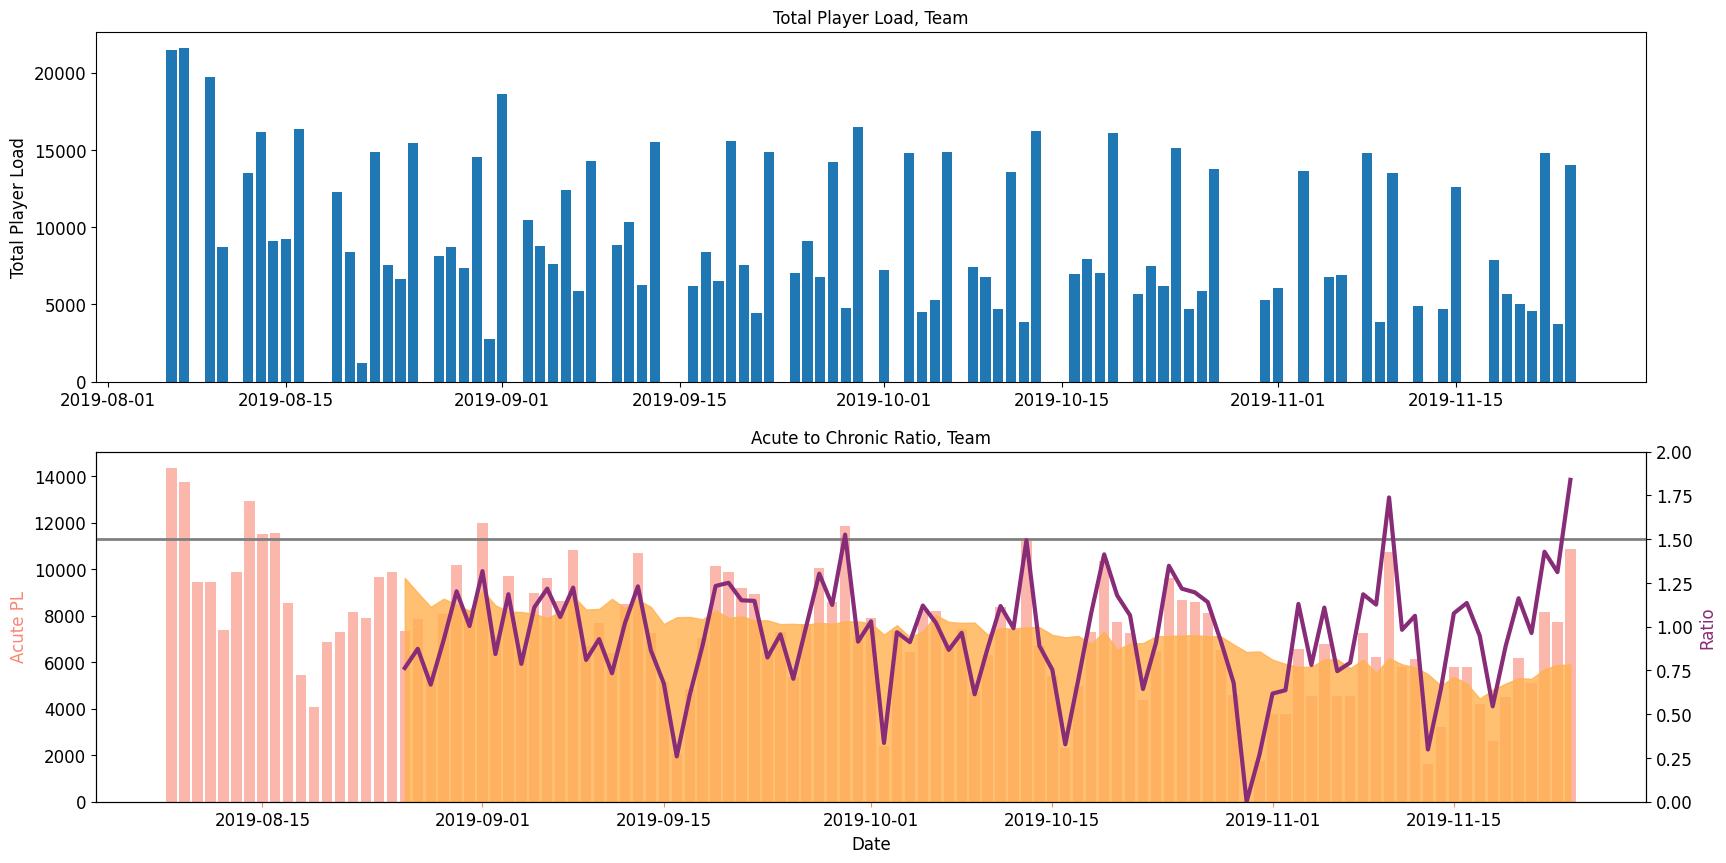

In [73]:
fig, axs = plt.subplots(2,figsize=(20, 10))

axs[0].bar(df_all.index, df_all["Total.Player.Load"])
#axs[0].set_xlabel("Date", fontsize=12)
axs[0].tick_params(axis='x', labelsize=12)
axs[0].set_ylabel('Total Player Load', fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)
axs[0].set_title("Total Player Load, Team", fontsize=12)

color='#FA8775'
axs[1].set_xlabel("Date", fontsize=12)
axs[1].tick_params(axis='x', labelsize=12, color=color)
axs[1].set_ylabel('Acute PL', color=color, fontsize=12)
axs[1].bar(df_all.index, df_all["Acute_PL"], color=color, alpha=0.6)
axs[1].tick_params(axis='y', labelsize=12)

color='#FFB14E'
axs[1].fill_between(df_all.index, df_all["Chronic_PL"], color=color, alpha=0.8)
axs[1] = plt.gca()
axs[1].set_title("Acute to Chronic Ratio, Team", fontsize=12)
axs1 = axs[1].twinx()  # instantiate a second axes that shares the same x-axis

color='#882C78'
axs1.set_ylabel('Ratio', fontsize=12, color=color)  # we already handled the x-label with ax1
axs1.plot(df_all.index, df_all["Acute:Chronic"], color=color, linewidth=3.0)
axs1.tick_params(axis='y', labelsize=12)
axs1 = plt.gca()

# To see how the acute to chronic workload ratio drops over the first 28 days,
# comment out this line by adding a '#' in front of the line
axs1.set_ylim([0,2.0])

axs1.axhline(y=1.5,c="gray",linewidth=2,zorder=0)

### Step 9

In [74]:
# Identify any dates that the team went above the 1.5 threshold for the ACWR (3:21)
df_all.nlargest(5, 'Acute:Chronic')

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,,,,
2019-11-24,806,SessionSessionSessionSessionSessionSessionSess...,DFFDFDMMDFMMDDMFD,14027.23956,141.80282,1751,0,1432.14411,1558.522129,10856.481493,5902.242050,1.839383
2019-11-10,840,SessionSessionSessionSessionSessionSessionSess...,DFDDFDDFMMFMMMDMFD,13527.89556,143.96280,2777,373,2265.97600,1552.761600,10746.631557,6181.182352,1.738605
2019-09-29,1031,SessionSessionSessionSessionSessionSessionSess...,DFFDDFDDFMMDFMMMDDDMFD,16510.51763,160.57588,3930,503,2935.97880,1955.542138,11844.918730,7760.283862,1.526351
2019-10-13,888,SessionSessionSessionSessionSessionSessionSess...,DFFDDFDFMMDFMMDDDMFD,16228.67178,160.58473,3357,223,2586.65682,1933.122200,11224.619850,7513.621718,1.493903
2019-11-22,855,SessionSessionSessionSessionSessionSessionSess...,DFFDFDFMMDFMMDDMFD,14833.59227,148.70177,2326,0,2063.29903,1680.056468,8150.606677,5705.682994,1.428507


By getting the 5 highest dates of ACWR, we can see that the team went above the 1.5 threshold three times on the dates of November 24th, November 10th, and September 29th.

### Step 10

In [75]:
# Identify the lowest (non-zero) cumulative team session duration (ie. what day did the team have the least number of minutes in practice).
# When did this fall relative to the teams schedule?
df_all[df_all['Session.Duration'] != 0].nsmallest(1, 'Session.Duration')

,Player.Name,Period.Name,Position.Name,Total.Player.Load,Player.Load.Per.Minute,Maximum.Heart.Rate,Minimum.Heart.Rate,Avg.Heart.Rate,Session.Duration,Acute_PL,Chronic_PL,Acute:Chronic
Date,,,,,,,,,,,,
2019-08-21,651,SessionSessionSessionSessionSessionSessionSess...,DFFDFDMMDDDMF,1223.74407,33.08703,1815,542,1453.59259,379.616189,7290.63043,NaN,NaN


We can see the shortest session that was non-zero occured on August 21st.  In terms of the team schedule, this practice occured the day before the second game of the season.